In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import os

In [15]:
taxi_files = [filename for filename in os.listdir('data') if 'nyc_taxi' in filename and '2020' in filename]

In [16]:
taxi_files

['nyc_taxi_2020-01.csv', 'nyc_taxi_2020-07.csv']

In [17]:
dataframes = []
for filename in taxi_files:
    df = pd.read_csv(
        'data/' + filename,
        usecols=[
            'tpep_pickup_datetime',
            'passenger_count',
            'trip_distance',
            'total_amount',
        ],
        parse_dates=['tpep_pickup_datetime']
    )
    dataframes.append(df)

In [18]:
df = pd.concat(objs=dataframes, ignore_index=True)
df

,tpep_pickup_datetime,passenger_count,trip_distance,total_amount
0,2020-01-01 00:28:15,1.0,1.20,11.27
1,2020-01-01 00:35:39,1.0,1.20,12.30
2,2020-01-01 00:47:41,1.0,0.60,10.80
3,2020-01-01 00:55:23,1.0,0.80,8.16
4,2020-01-01 00:01:58,1.0,0.00,4.80
...,...,...,...,...
7205415,2020-07-19 13:27:52,NaN,24.23,83.50
7205416,2020-07-19 13:02:00,NaN,4.40,19.78
7205417,2020-07-19 13:32:00,NaN,8.78,38.45
7205418,2020-07-19 13:28:00,NaN,6.50,29.77


In [19]:
df['year'] = df['tpep_pickup_datetime'].dt.year

In [20]:
df['month'] = df['tpep_pickup_datetime'].dt.month

In [21]:
df['day'] = df['tpep_pickup_datetime'].dt.day

In [22]:
df

,tpep_pickup_datetime,passenger_count,trip_distance,total_amount,year,month,day
0,2020-01-01 00:28:15,1.0,1.20,11.27,2020,1,1
1,2020-01-01 00:35:39,1.0,1.20,12.30,2020,1,1
2,2020-01-01 00:47:41,1.0,0.60,10.80,2020,1,1
3,2020-01-01 00:55:23,1.0,0.80,8.16,2020,1,1
4,2020-01-01 00:01:58,1.0,0.00,4.80,2020,1,1
...,...,...,...,...,...,...,...
7205415,2020-07-19 13:27:52,NaN,24.23,83.50,2020,7,19
7205416,2020-07-19 13:02:00,NaN,4.40,19.78,2020,7,19
7205417,2020-07-19 13:32:00,NaN,8.78,38.45,2020,7,19
7205418,2020-07-19 13:28:00,NaN,6.50,29.77,2020,7,19


In [23]:
df = df.loc[(df['year'] == 2020) & (df['month'].isin([1, 7]))]

In [24]:
df

,tpep_pickup_datetime,passenger_count,trip_distance,total_amount,year,month,day
0,2020-01-01 00:28:15,1.0,1.20,11.27,2020,1,1
1,2020-01-01 00:35:39,1.0,1.20,12.30,2020,1,1
2,2020-01-01 00:47:41,1.0,0.60,10.80,2020,1,1
3,2020-01-01 00:55:23,1.0,0.80,8.16,2020,1,1
4,2020-01-01 00:01:58,1.0,0.00,4.80,2020,1,1
...,...,...,...,...,...,...,...
7205415,2020-07-19 13:27:52,NaN,24.23,83.50,2020,7,19
7205416,2020-07-19 13:02:00,NaN,4.40,19.78,2020,7,19
7205417,2020-07-19 13:32:00,NaN,8.78,38.45,2020,7,19
7205418,2020-07-19 13:28:00,NaN,6.50,29.77,2020,7,19


In [25]:
df = df.reset_index(drop=True)

In [26]:
df

,tpep_pickup_datetime,passenger_count,trip_distance,total_amount,year,month,day
0,2020-01-01 00:28:15,1.0,1.20,11.27,2020,1,1
1,2020-01-01 00:35:39,1.0,1.20,12.30,2020,1,1
2,2020-01-01 00:47:41,1.0,0.60,10.80,2020,1,1
3,2020-01-01 00:55:23,1.0,0.80,8.16,2020,1,1
4,2020-01-01 00:01:58,1.0,0.00,4.80,2020,1,1
...,...,...,...,...,...,...,...
7205199,2020-07-19 13:27:52,NaN,24.23,83.50,2020,7,19
7205200,2020-07-19 13:02:00,NaN,4.40,19.78,2020,7,19
7205201,2020-07-19 13:32:00,NaN,8.78,38.45,2020,7,19
7205202,2020-07-19 13:28:00,NaN,6.50,29.77,2020,7,19


In [27]:
df = df.sample(frac=0.01)

In [28]:
df

,tpep_pickup_datetime,passenger_count,trip_distance,total_amount,year,month,day
1467815,2020-01-09 08:39:56,0.0,5.80,23.80,2020,1,9
3373535,2020-01-17 20:54:11,1.0,2.00,19.20,2020,1,17
5661784,2020-01-29 07:10:23,1.0,9.08,32.30,2020,1,29
1573553,2020-01-09 16:09:52,1.0,0.93,9.80,2020,1,9
3805030,2020-01-20 10:32:42,5.0,1.01,12.96,2020,1,20
...,...,...,...,...,...,...,...
1979623,2020-01-11 13:21:22,1.0,4.02,18.16,2020,1,11
1864462,2020-01-10 21:32:45,2.0,1.60,11.80,2020,1,10
4880996,2020-01-25 10:45:30,1.0,1.67,13.56,2020,1,25
366602,2020-01-03 09:35:57,1.0,0.80,10.55,2020,1,3


In [29]:
df.index.is_unique

True

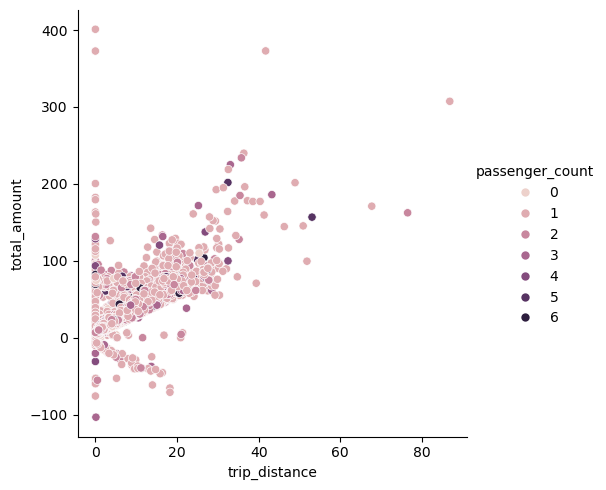

In [30]:
sns.relplot(x='trip_distance', y='total_amount', data=df, hue='passenger_count')

In [33]:
df.groupby(by=['month', 'day'])['trip_distance'].mean().to_frame().reset_index()

,month,day,trip_distance
0,1,1,3.533772
1,1,2,3.234054
2,1,3,2.941417
3,1,4,3.048911
4,1,5,3.248338
...,...,...,...
57,7,27,2.970350
58,7,28,2.979772
59,7,29,2.746825
60,7,30,3.075242


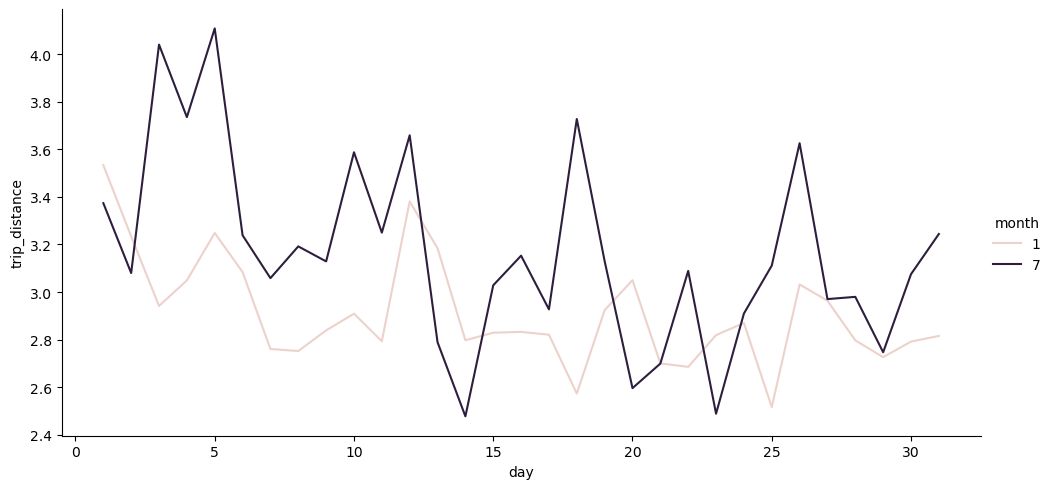

In [55]:
sns.relplot(x='day', y='trip_distance', data=df.groupby(by=['month', 'day'])['trip_distance'].mean().to_frame().reset_index(), hue='month', kind='line', height=5, aspect=2)

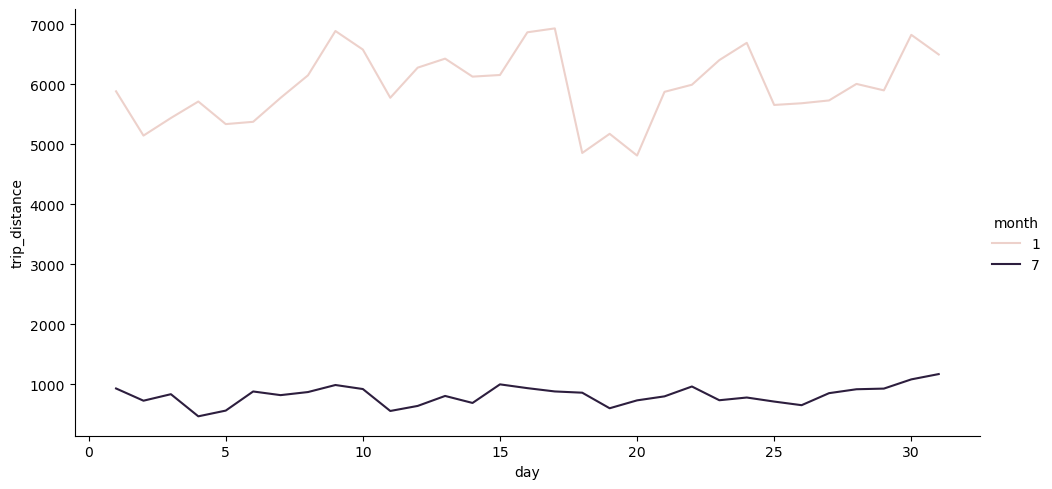

In [56]:
sns.relplot(x='day', y='trip_distance', data=df.groupby(by=['month', 'day'])['trip_distance'].sum().to_frame().reset_index(), hue='month', kind='line', height=5, aspect=2)

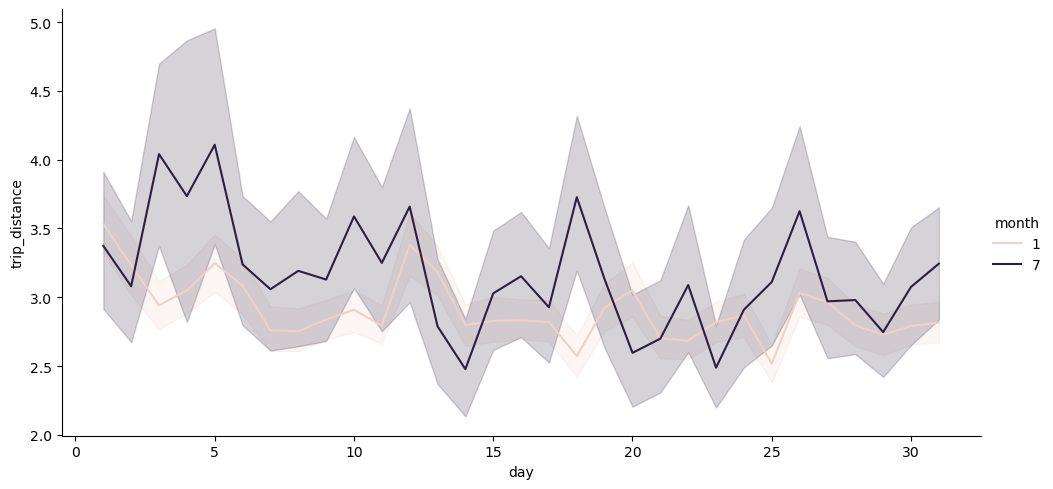

In [63]:
sns.relplot(x='day', y='trip_distance', data=df, hue='month', kind='line', height=5, aspect=2)

In [60]:
df.groupby(by=['month', 'day'])['tpep_pickup_datetime'].count().to_frame().reset_index().rename(columns={'tpep_pickup_datetime': 'trips_count'})

,month,day,trips_count
0,1,1,1665
1,1,2,1591
2,1,3,1849
3,1,4,1874
4,1,5,1643
...,...,...,...
57,7,27,286
58,7,28,307
59,7,29,337
60,7,30,351


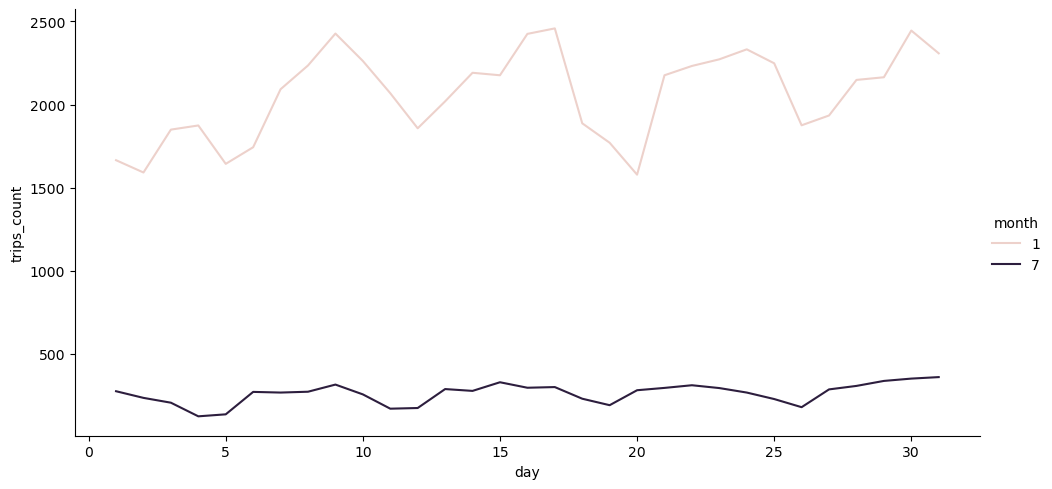

In [47]:
sns.relplot(x='day', y='trips_count', data=trips, hue='month', kind='line', height=5, aspect=2)

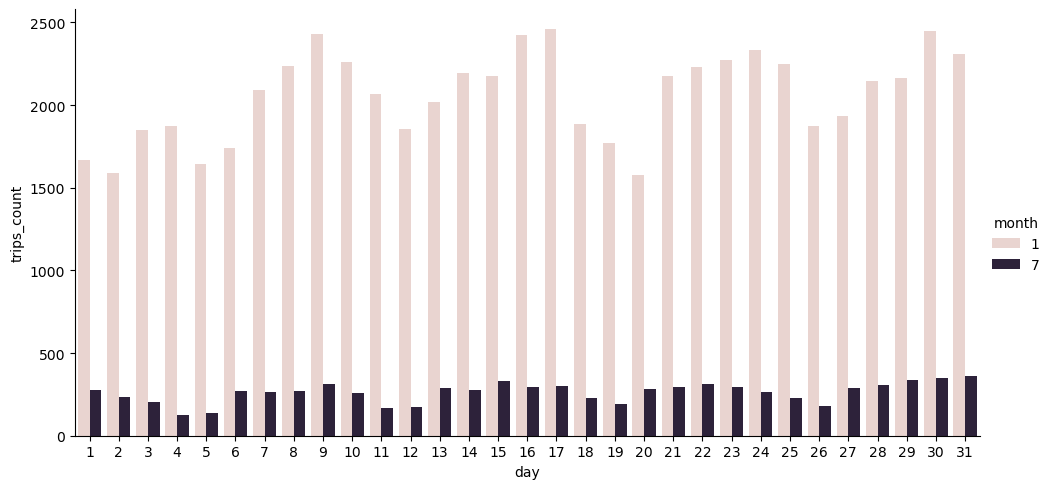

In [46]:
sns.catplot(x='day', y='trips_count', data=trips, hue='month', kind='bar',height=5, aspect=2)

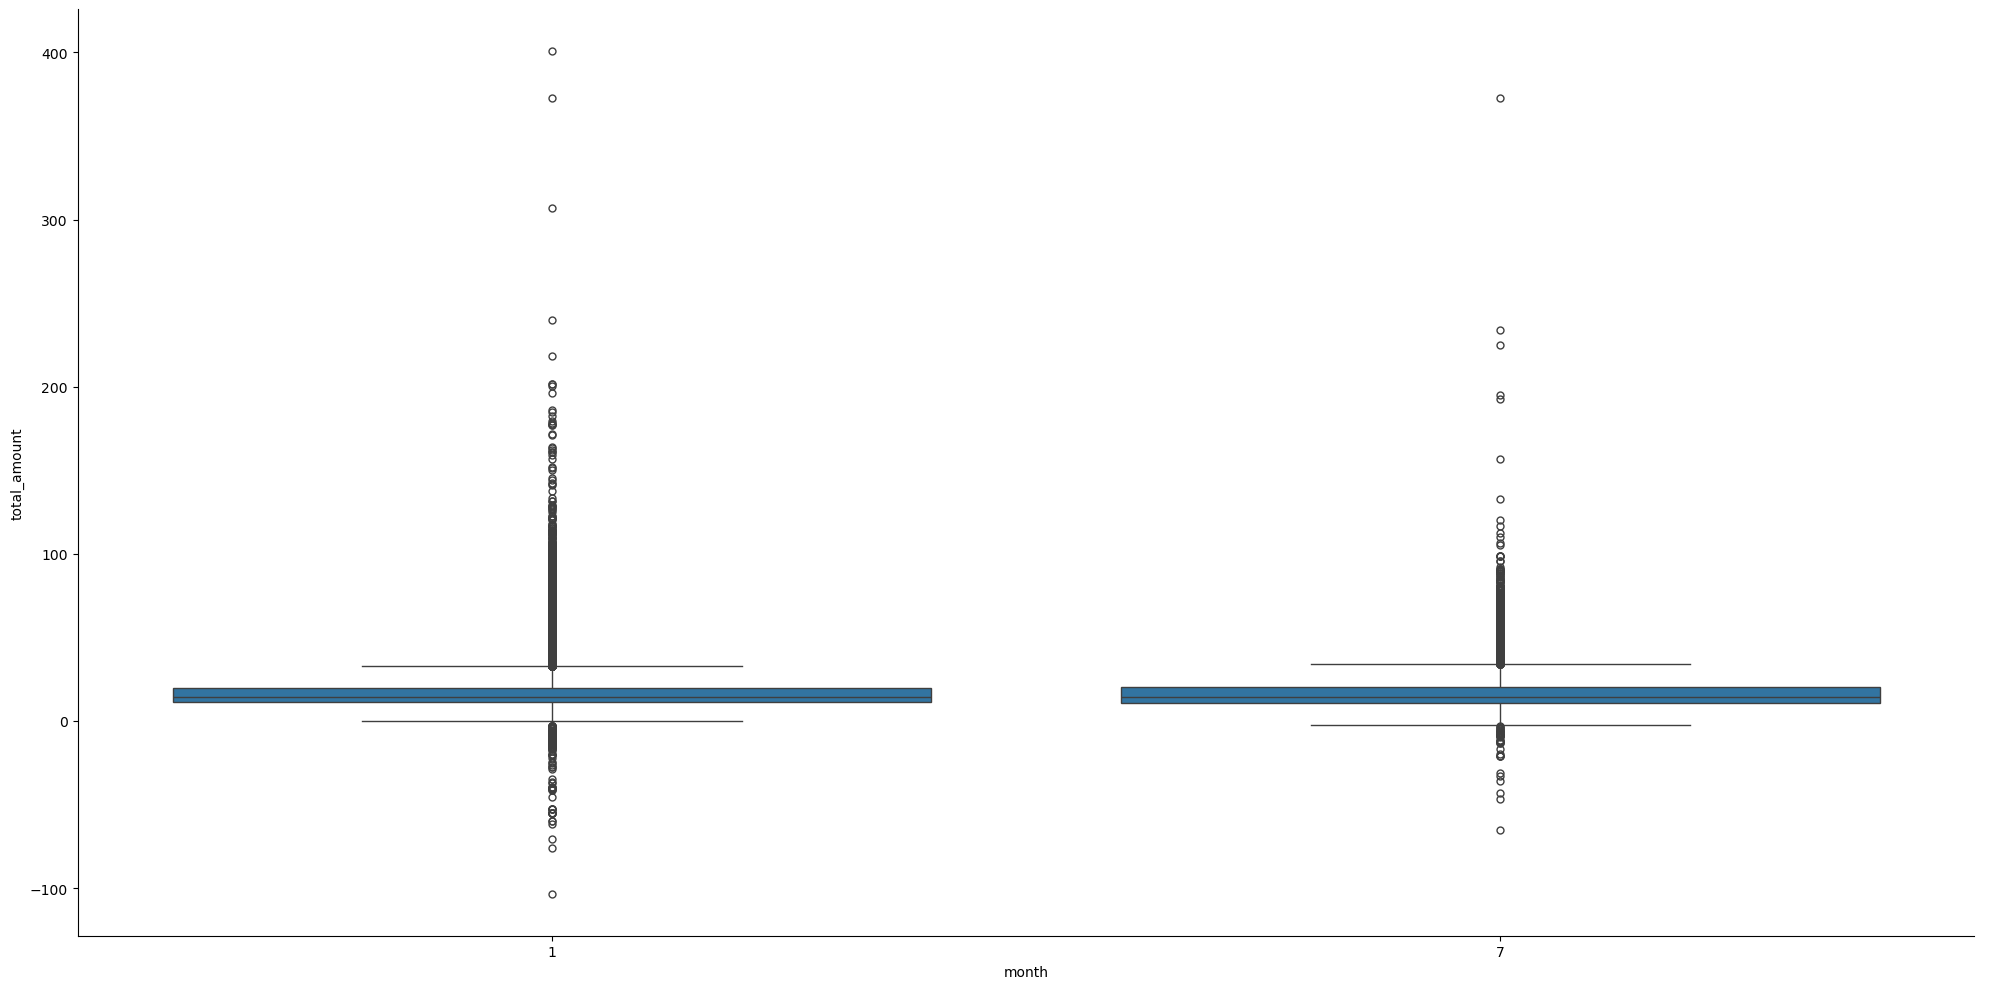

In [64]:
sns.catplot(data=df, x='month', y='total_amount', kind='box', height=10, aspect=2)

In [65]:
# 47.1

In [66]:
taxi_files = [filename for filename in os.listdir('data') if 'nyc_taxi' in filename]

In [67]:
dataframes = []
for filename in taxi_files:
    df = pd.read_csv(
        'data/' + filename,
        usecols=[
            'tpep_pickup_datetime',
            'passenger_count',
            'trip_distance',
            'total_amount',
        ],
        parse_dates=['tpep_pickup_datetime']
    )
    dataframes.append(df)

In [68]:
df = pd.concat(objs=dataframes, ignore_index=True, axis=0)
df

,tpep_pickup_datetime,passenger_count,trip_distance,total_amount
0,2020-01-01 00:28:15,1.0,1.20,11.27
1,2020-01-01 00:35:39,1.0,1.20,12.30
2,2020-01-01 00:47:41,1.0,0.60,10.80
3,2020-01-01 00:55:23,1.0,0.80,8.16
4,2020-01-01 00:01:58,1.0,0.00,4.80
...,...,...,...,...
21183626,2019-01-31 23:57:36,1.0,4.79,23.16
21183627,2019-01-31 23:32:03,1.0,0.00,0.00
21183628,2019-01-31 23:36:36,1.0,0.00,0.00
21183629,2019-01-31 23:14:53,1.0,0.00,0.00


In [69]:
df.dtypes

tpep_pickup_datetime    datetime64[ns]
passenger_count                float64
trip_distance                  float64
total_amount                   float64
dtype: object

In [70]:
df['year'] = df['tpep_pickup_datetime'].dt.year

In [71]:
df['month'] = df['tpep_pickup_datetime'].dt.month

In [72]:
df['day'] = df['tpep_pickup_datetime'].dt.day

In [73]:
df = df.loc[(df['year'].isin([2019, 2020])) & (df['month'].isin([1, 7]))]

In [74]:
df

,tpep_pickup_datetime,passenger_count,trip_distance,total_amount,year,month,day
0,2020-01-01 00:28:15,1.0,1.20,11.27,2020,1,1
1,2020-01-01 00:35:39,1.0,1.20,12.30,2020,1,1
2,2020-01-01 00:47:41,1.0,0.60,10.80,2020,1,1
3,2020-01-01 00:55:23,1.0,0.80,8.16,2020,1,1
4,2020-01-01 00:01:58,1.0,0.00,4.80,2020,1,1
...,...,...,...,...,...,...,...
21183626,2019-01-31 23:57:36,1.0,4.79,23.16,2019,1,31
21183627,2019-01-31 23:32:03,1.0,0.00,0.00,2019,1,31
21183628,2019-01-31 23:36:36,1.0,0.00,0.00,2019,1,31
21183629,2019-01-31 23:14:53,1.0,0.00,0.00,2019,1,31


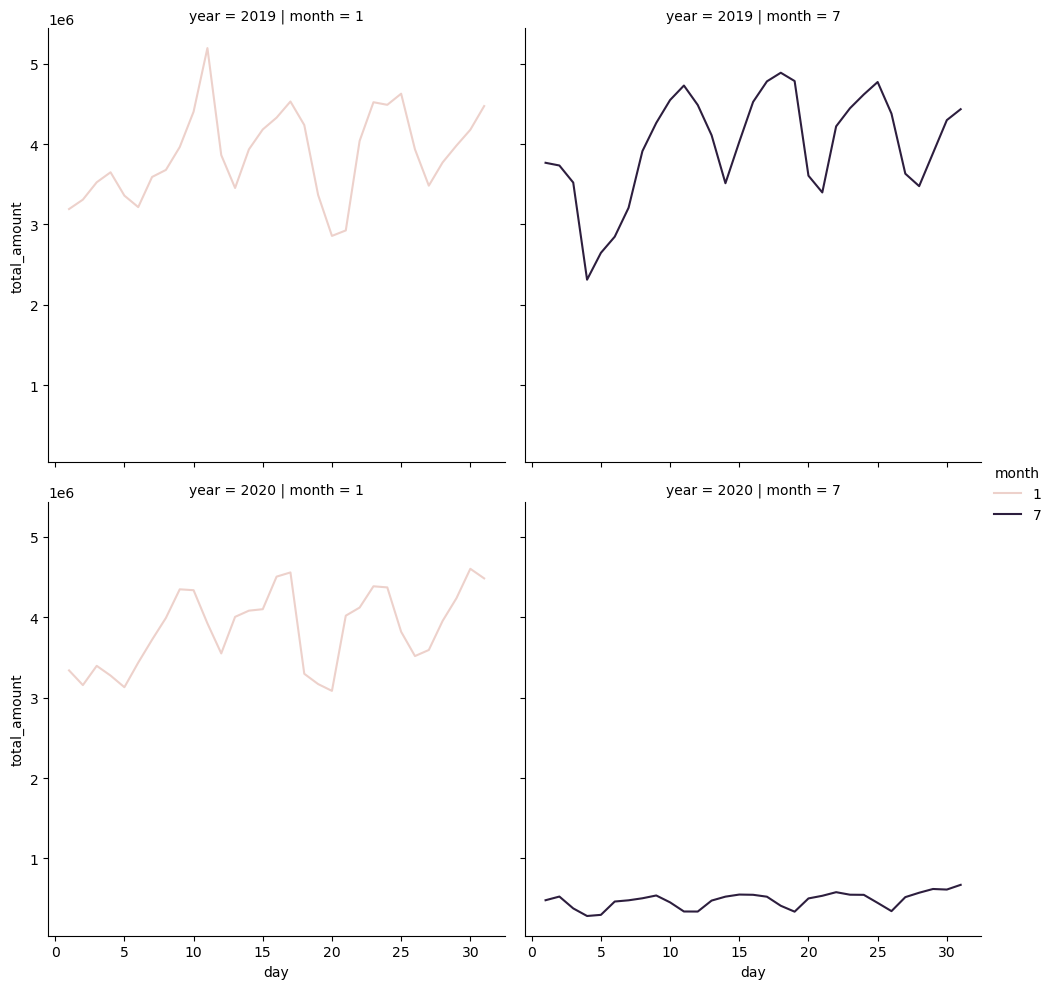

In [79]:
sns.relplot(data=df.groupby(by=['year', 'month', 'day'])['total_amount'].sum().reset_index(), x='day', y='total_amount', kind='line', row='year', col='month', hue='month')

In [80]:
# 46.2

In [81]:
def get_distance_category(distance):
    if distance <= 2:
        return 'short'
    elif 2 < distance <= 10:
        return 'medium'
    else:
        return 'long'

In [83]:
df.loc[:, 'trip_length'] = df['trip_distance'].apply(get_distance_category)

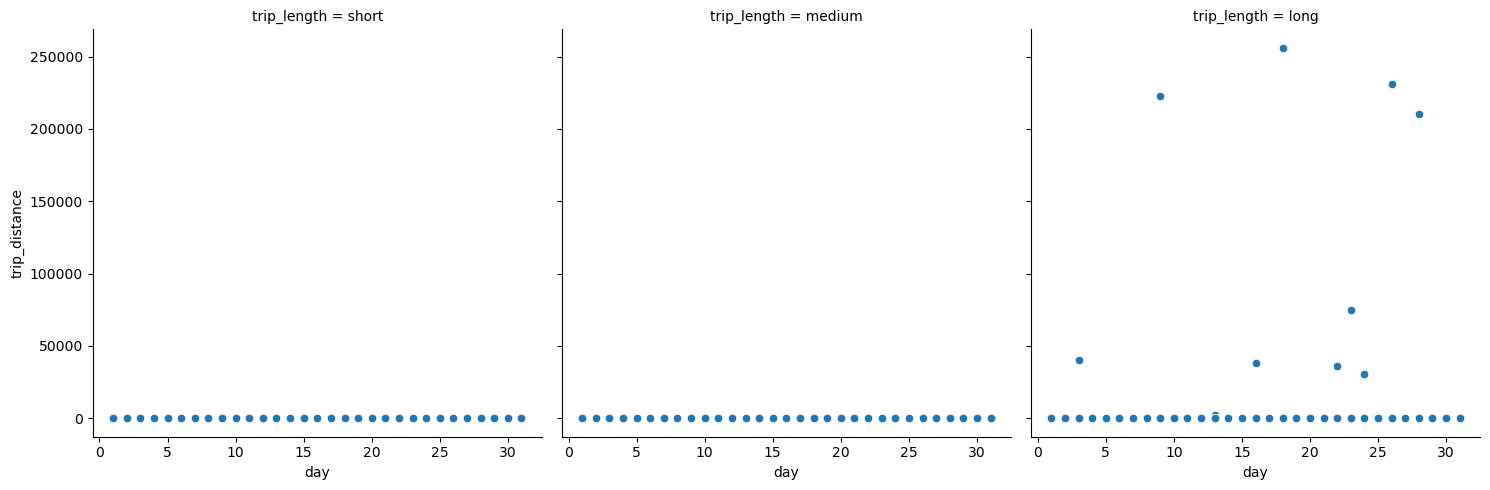

In [87]:
sns.relplot(x='day', y='trip_distance', data=df, col='trip_length')

In [88]:
# 43.3

In [90]:
df.loc[:, 'hour'] = df['tpep_pickup_datetime'].dt.hour

In [91]:
df.head()

,tpep_pickup_datetime,passenger_count,trip_distance,total_amount,year,month,day,trip_length,hour
0,2020-01-01 00:28:15,1.0,1.2,11.27,2020,1,1,short,0
1,2020-01-01 00:35:39,1.0,1.2,12.30,2020,1,1,short,0
2,2020-01-01 00:47:41,1.0,0.6,10.80,2020,1,1,short,0
3,2020-01-01 00:55:23,1.0,0.8,8.16,2020,1,1,short,0
4,2020-01-01 00:01:58,1.0,0.0,4.80,2020,1,1,short,0


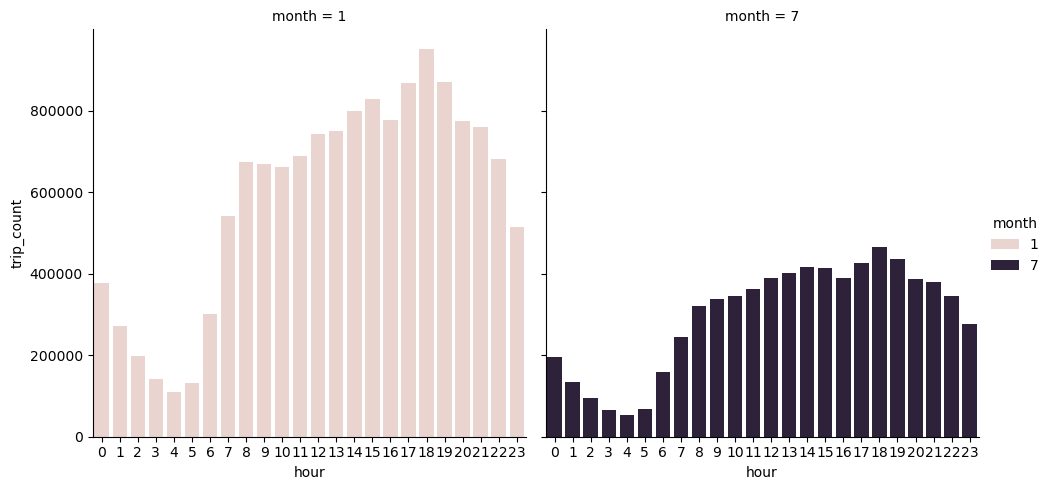

In [92]:
sns.catplot(x='hour', y='trip_count', kind='bar', col='month', hue='month', data=df.groupby(by=['month', 'hour'])['tpep_pickup_datetime'].count().reset_index().rename(columns={'tpep_pickup_datetime': 'trip_count'}))